In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# =============================
# Data Handling
# =============================
import pandas as pd
import numpy as np

# =============================
# Visualization
# =============================
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# Machine Learning
# =============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# =============================
# Advanced Model
# =============================
from xgboost import XGBClassifier

# =============================
# Deep Learning
# =============================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# =============================
# Ignore Warnings
# =============================
import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'xgboost'

In [4]:
df = pd.read_csv("../data/newborn_health_monitoring_with_risk.csv")
df.head()

,baby_id,name,gender,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,date,age_days,weight_kg,...,oxygen_saturation,feeding_type,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score,immunizations_done,reflexes_normal,risk_level
0,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-10,1,3.28,...,98,Formula,11,9,0,4.2,7.0,Yes,Yes,At Risk
1,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-11,2,3.35,...,99,Formula,11,5,2,10.6,NaN,No,No,At Risk
2,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-12,3,3.35,...,97,Breastfeeding,7,6,5,9.8,NaN,No,No,Healthy
3,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-13,4,3.48,...,97,Mixed,11,8,4,8.1,NaN,No,Yes,Healthy
4,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-14,5,3.50,...,96,Breastfeeding,11,7,1,11.6,NaN,No,Yes,At Risk


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   baby_id                      3000 non-null   object 
 1   name                         3000 non-null   object 
 2   gender                       3000 non-null   object 
 3   gestational_age_weeks        3000 non-null   float64
 4   birth_weight_kg              3000 non-null   float64
 5   birth_length_cm              3000 non-null   float64
 6   birth_head_circumference_cm  3000 non-null   float64
 7   date                         3000 non-null   object 
 8   age_days                     3000 non-null   int64  
 9   weight_kg                    3000 non-null   float64
 10  length_cm                    3000 non-null   float64
 11  head_circumference_cm        3000 non-null   float64
 12  temperature_c                3000 non-null   float64
 13  heart_rate_bpm    

In [6]:
df.describe()

,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,age_days,weight_kg,length_cm,head_circumference_cm,temperature_c,heart_rate_bpm,respiratory_rate_bpm,oxygen_saturation,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,100.000000
mean,38.878000,3.205000,49.727000,34.128000,15.500000,3.669730,50.508000,34.438900,37.002933,139.682000,39.421333,97.473000,9.450000,6.470000,2.448333,4.163467,8.400000
std,1.570076,0.561555,2.145065,1.486254,8.656884,0.621355,2.196846,1.500893,0.310747,10.139386,4.999481,1.048318,1.707182,1.700803,1.699106,2.861971,1.163415
min,35.400000,1.860000,45.100000,31.200000,1.000000,1.790000,45.000000,31.100000,35.800000,100.000000,23.000000,94.000000,7.000000,4.000000,0.000000,0.000000,7.000000
25%,37.800000,2.870000,48.475000,32.975000,8.000000,3.220000,49.100000,33.300000,36.800000,133.000000,36.000000,97.000000,8.000000,5.000000,1.000000,2.500000,7.000000
50%,38.800000,3.165000,49.550000,34.100000,15.500000,3.660000,50.400000,34.400000,37.000000,140.000000,39.000000,97.000000,9.000000,6.000000,2.000000,3.300000,8.000000
75%,40.100000,3.625000,51.025000,34.800000,23.000000,4.100000,51.800000,35.300000,37.200000,146.000000,43.000000,98.000000,11.000000,8.000000,4.000000,4.300000,9.250000
max,43.000000,4.470000,55.800000,38.100000,30.000000,5.410000,57.400000,38.700000,38.100000,173.000000,57.000000,101.000000,12.000000,9.000000,5.000000,15.000000,10.000000


In [7]:
df.shape

(3000, 25)

In [8]:
df.columns

Index(['baby_id', 'name', 'gender', 'gestational_age_weeks', 'birth_weight_kg',
       'birth_length_cm', 'birth_head_circumference_cm', 'date', 'age_days',
       'weight_kg', 'length_cm', 'head_circumference_cm', 'temperature_c',
       'heart_rate_bpm', 'respiratory_rate_bpm', 'oxygen_saturation',
       'feeding_type', 'feeding_frequency_per_day', 'urine_output_count',
       'stool_count', 'jaundice_level_mg_dl', 'apgar_score',
       'immunizations_done', 'reflexes_normal', 'risk_level'],
      dtype='object')

In [9]:
df['risk_level'].value_counts()

risk_level
Healthy    2602
At Risk     398
Name: count, dtype: int64

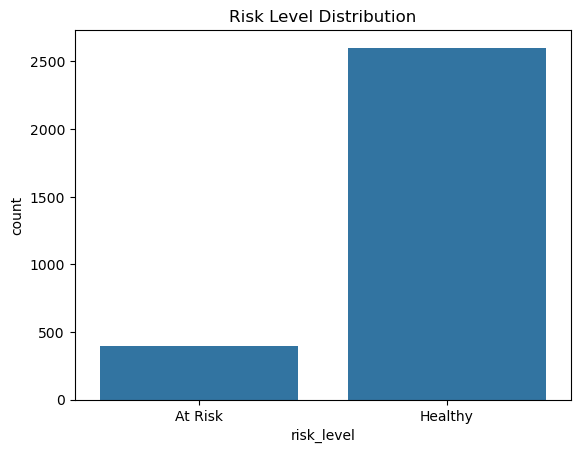

In [10]:
sns.countplot(x='risk_level', data=df)
plt.title("Risk Level Distribution")
plt.show()

In [11]:
df['risk_level'].unique()

array(['At Risk', 'Healthy'], dtype=object)

In [12]:
df['risk_level'] = df['risk_level'].map({
    'Healthy': 0,
    'At Risk': 1
})

In [13]:
df['risk_level'].value_counts()

risk_level
0    2602
1     398
Name: count, dtype: int64

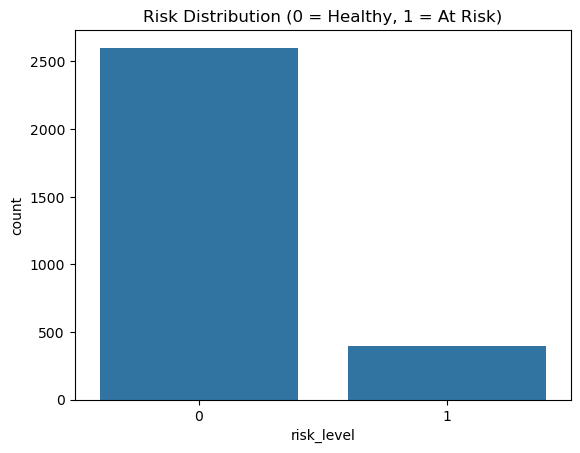

In [14]:
sns.countplot(x='risk_level', data=df)
plt.title("Risk Distribution (0 = Healthy, 1 = At Risk)")
plt.show()

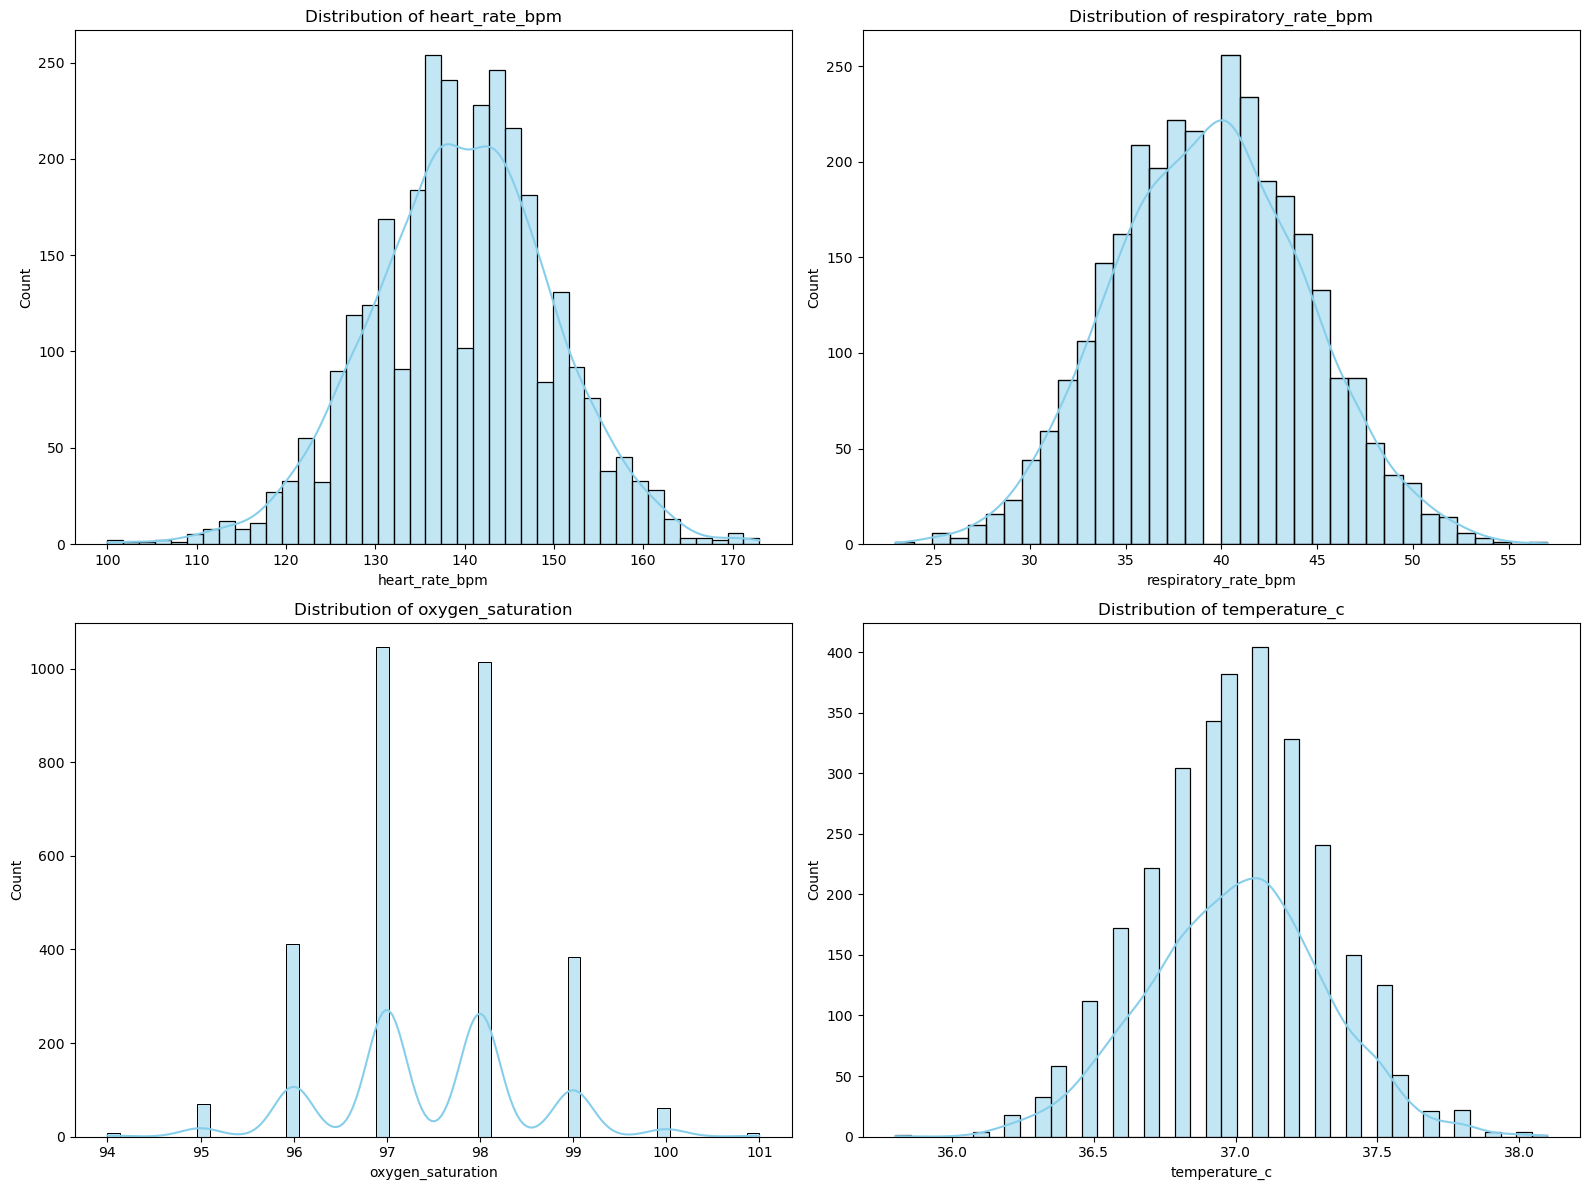

In [15]:
plt.figure(figsize=(16, 12))
vitals = ['heart_rate_bpm', 'respiratory_rate_bpm', 'oxygen_saturation', 'temperature_c']
for i, feature in enumerate(vitals, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True, color='skyblue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

In [16]:
comparison = df.groupby('risk_level')[vitals].agg(['mean', 'std'])
display(comparison)

comparison = df.groupby('risk_level')[vitals].agg(['min', 'max'])
display(comparison) 

print(df['risk_level'].value_counts(normalize=True) * 100)

heart_rate_bpm            respiratory_rate_bpm            \
                     mean        std                 mean       std   
risk_level                                                            
0              139.124520   9.576854            39.399308  5.023594   
1              143.326633  12.663991            39.565327  4.842559   

           oxygen_saturation           temperature_c            
                        mean       std          mean       std  
risk_level                                                      
0                  97.536510  0.973511     36.998155  0.310059  
1                  97.057789  1.376001     37.034171  0.313810

heart_rate_bpm      respiratory_rate_bpm     oxygen_saturation  \
                      min  max                  min max               min   
risk_level                                                                  
0                     100  159                   23  55                96   
1                     106  173                   25  57                94   

                temperature_c        
            max           min   max  
risk_level                           
0           101          35.8  37.9  
1           101          36.2  38.1

risk_level
0    86.733333
1    13.266667
Name: proportion, dtype: float64


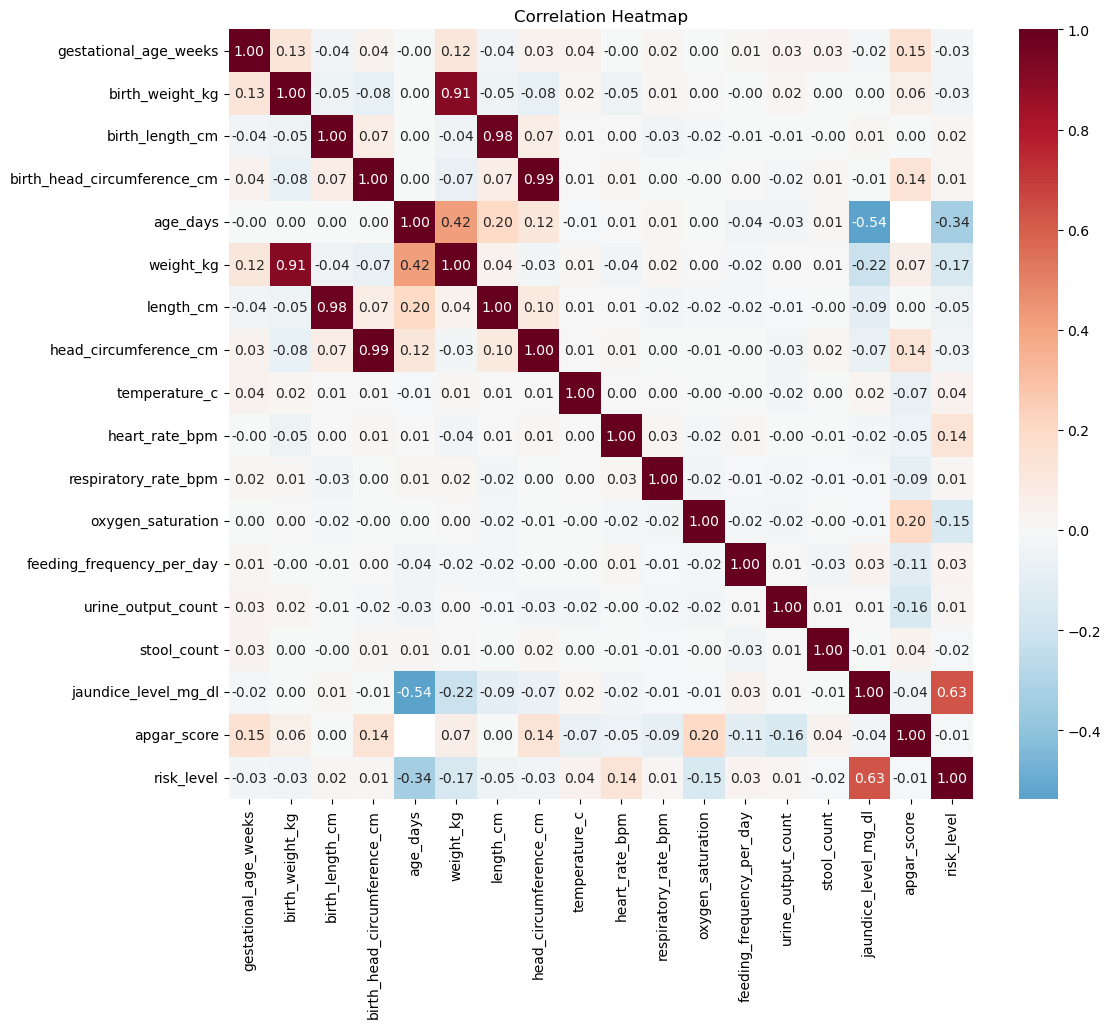

In [17]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

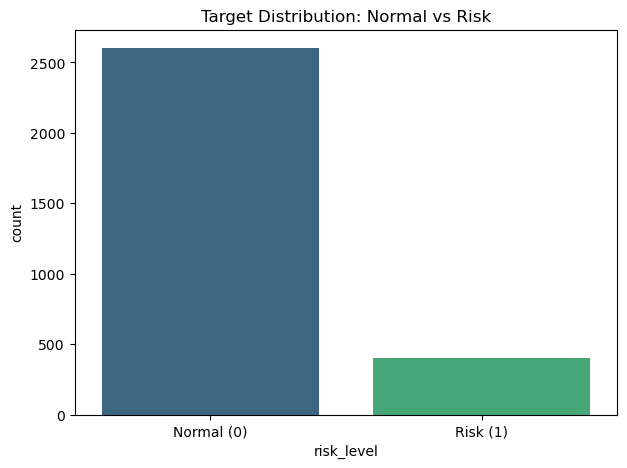

In [18]:
plt.figure(figsize=(7, 5))
sns.countplot(x='risk_level', data=df, palette='viridis')
plt.xticks([0, 1], ['Normal (0)', 'Risk (1)'])
plt.title('Target Distribution: Normal vs Risk')
plt.show()

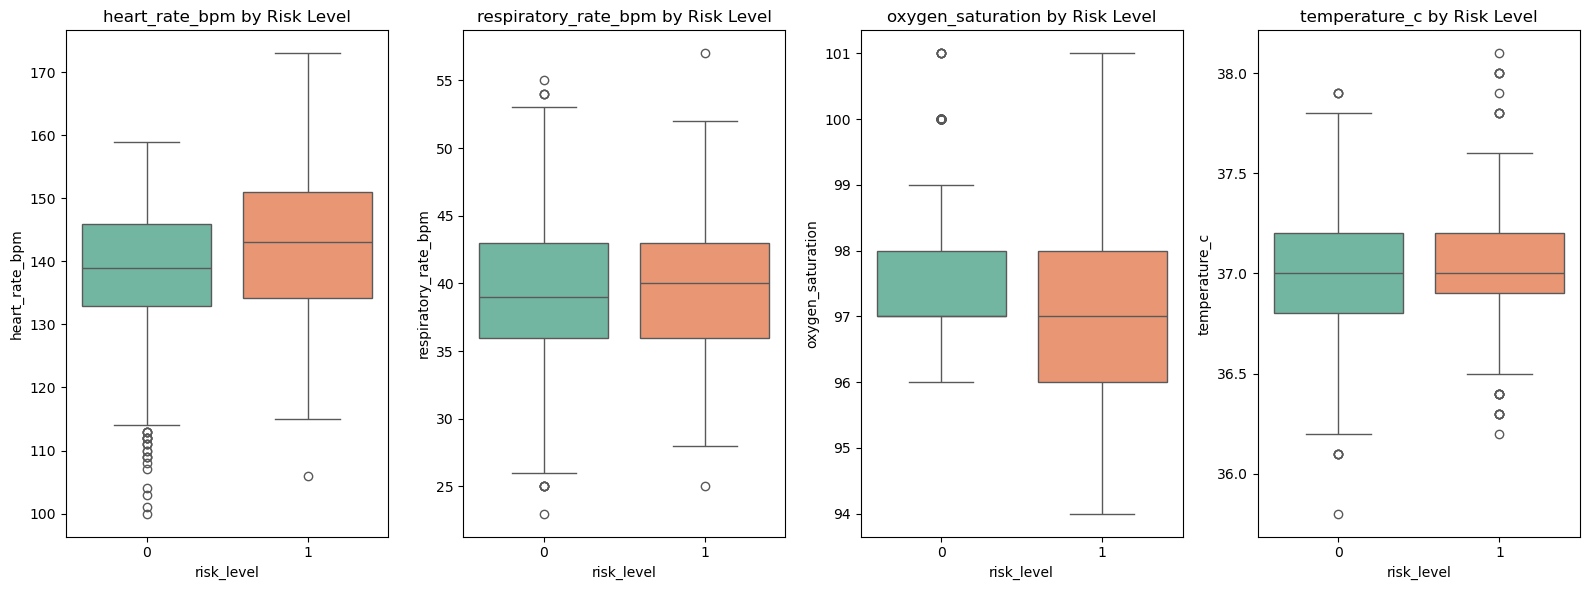

In [19]:
plt.figure(figsize=(16, 6))
for i, feature in enumerate(vitals, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(x='risk_level', y=feature, data=df, palette='Set2')
    plt.title(f'{feature} by Risk Level')
plt.tight_layout()
plt.show()

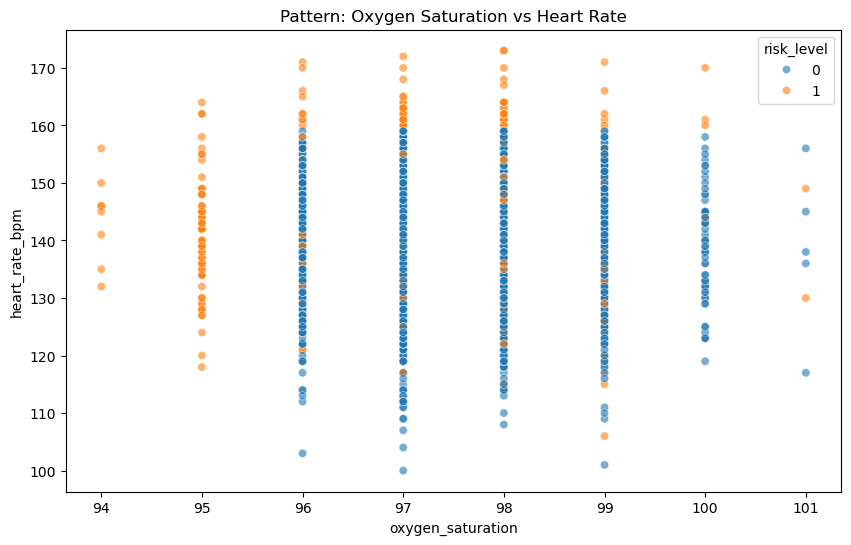

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='oxygen_saturation', y='heart_rate_bpm', hue='risk_level', data=df, alpha=0.6)
plt.title('Pattern: Oxygen Saturation vs Heart Rate')
plt.show()

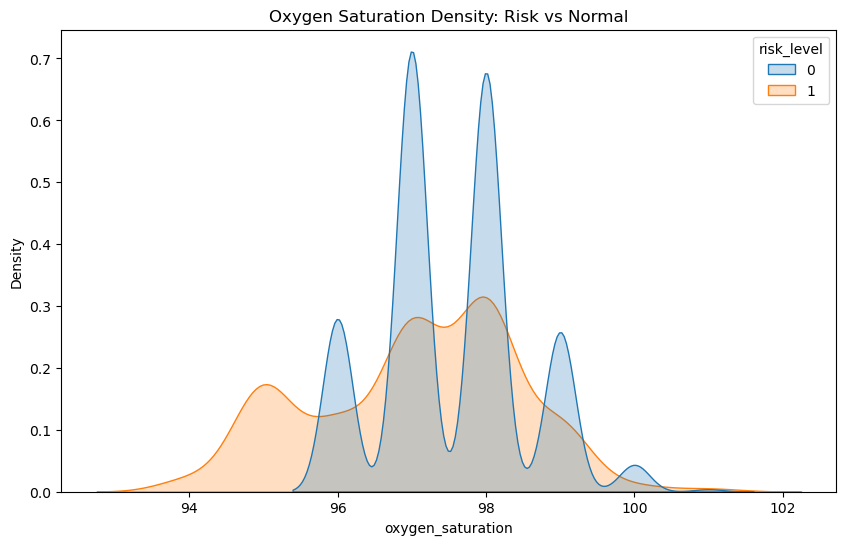

In [21]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='oxygen_saturation', hue='risk_level', fill=True, common_norm=False)
plt.title('Oxygen Saturation Density: Risk vs Normal')
plt.show()